# Notebook 2 — Estimação da Janela Pré-ictal e Rotulagem

Segundo estágio do pipeline. Executa três tarefas:

1. **Estimação empírica** da duração da janela pré-ictal por detecção de
   pontos de mudança (PELT), agora reportada **por paciente** (seção 4.1),
   não só como uma mediana global — evidência direta para a pergunta "existe
   um pré-ictal universal, ou ele é específico de cada paciente?" (Paper 2).
2. **Rotulagem com múltiplas janelas fixas** — cada gravação é rotulada uma
   vez para cada duração em `PREICTAL_WINDOWS_MIN` (15, 30, 45, 60 min,
   desenho do Paper 1), em vez de uma única `PRE_SEC` estimada. Isso permite
   comparar diretamente, nos notebooks seguintes, como a definição da janela
   afeta o desempenho e o tempo de antecedência da detecção.
3. Geração dos arquivos `_L1_w{N}.npz` (um por gravação, por janela),
   incluindo a obtenção do interictal a partir de gravações sem crise e de
   intervalos intra-arquivo.

## Mudança de nome de arquivo — importante para quem já rodou a versão anterior

A versão anterior deste notebook gravava um único `{ds}__{pat}__{fkey}_L1.npz`
por gravação. Esta versão grava **quatro** arquivos por gravação, com o nome
`{ds}__{pat}__{fkey}_L1_w15.npz`, `..._w30.npz`, `..._w45.npz`, `..._w60.npz`.

Os arquivos antigos (`..._L1.npz`, sem sufixo de janela) **não são
sobrescritos nem lidos** por este notebook — ficam órfãos em
`level1_signals/`. Se você já rodou a versão anterior, apague a pasta
`level1_signals/` inteira antes de rodar este notebook, para não misturar
o esquema antigo (1 arquivo por gravação) com o novo (4 arquivos por
gravação, com sufixo de janela).

## Motivação da estimação

A janela pré-ictal é o intervalo anterior à crise no qual o modelo deve detectar alterações. Defini-la arbitrariamente compromete a validade do classificador: se for longa demais, inclui sinal sem informação preditiva; se curta demais, descarta o período de transição. A estimação a partir dos próprios dados reduz esse arbítrio.

## Método

Para cada crise dos pacientes de calibração:

1. Extraem-se 15 features em janelas de 30 s ao longo dos 60 min anteriores ao início da crise, formando uma série temporal.
2. O algoritmo PELT detecta o ponto em que a dinâmica do sinal muda de regime.
3. K-Means (K=2) sobre as features, com índice de silhueta, avalia se a separação entre os dois estados é nítida; estimativas com silhueta acima do limiar são marcadas como confiáveis.
4. A distância entre o ponto de mudança e o início da crise é a duração estimada da janela pré-ictal para aquela crise.

A `PRE_SEC` final é a mediana de todas as estimativas válidas, limitada ao intervalo [5, 30] min, e aplicada uniformemente a todos os datasets.

## Obtenção do interictal

| Dataset | Fonte de interictal |
|---------|---------------------|
| CHB-MIT, SeizeIT2 | gravações sem crise (sinal inteiro) |
| Siena, Mendeley | intervalo intra-arquivo, distante das crises (pré e pós) |

Para o intervalo pós-crise, adota-se margem de 90 min após o fim da crise. Quando a margem de 60 min não produz interictal suficiente, ela é reduzida progressivamente (60, 45, 30 min) e o caso é registrado.

## Classes

| Rótulo | Classe | Definição |
|--------|--------|-----------|
| 0 | interictal | estado de base, distante de crises |
| 1 | pré-ictal | janela de `PRE_SEC` antes do início da crise |
| 2 | ictal | intervalo da crise (anotação clínica) |
| 3 | pós-ictal | intervalo de `POST_SEC` após o fim da crise |
| -1 | indefinido | zona de transição ao redor dos eventos |


## Nota — arquivos excluídos no Notebook 1

`chb12_28.edf` e `chb12_29.edf` (CHB-MIT) foram excluídos no Notebook 1 por
um erro de grafia do canal occipital no arquivo EDF original (`'01'` em vez
de `'O1'`). Como o pipeline lê os arquivos `_signal.npz` já filtrados pelo
NB1, essa exclusão já chega pronta aqui — nenhuma mudança de código é
necessária neste notebook por causa disso.

Vale registrar também que a estimação do `PRE_SEC` (seção 2 abaixo) usa
apenas canais com "hint" temporal (`TEMPORAL_HINTS`), não occipitais —
então essa exclusão não teria afetado a calibração mesmo se os arquivos
não tivessem sido removidos a montante.


## 1. Dependências e configuração

In [1]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

%pip install -q numpy pandas matplotlib scipy scikit-learn ruptures PyWavelets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, re, json, glob, gc, tempfile, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import ruptures as rpt
import pywt
import IPython.display as ipd
from tqdm.auto import tqdm

import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)

# Compatibilidade NumPy >= 2.0 (np.trapz renomeado para np.trapezoid)
if not hasattr(np, 'trapz'):
    np.trapz = np.trapezoid

# Diretórios
ROOT_DIR   = 'data'
SIGNAL_DIR = os.path.join(ROOT_DIR, 'signals')
L1_DIR     = os.path.join(ROOT_DIR, 'level1_signals')
VIZ_DIR    = os.path.join(ROOT_DIR, 'nb2_viz')
LOG_DIR    = os.path.join(ROOT_DIR, 'logs')
OUT_JSON   = os.path.join(ROOT_DIR, 'preictal_estimate.json')
for d in [L1_DIR, VIZ_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# Rótulos das classes
LBL = dict(interictal=0, preictal=1, ictal=2, postictal=3, unknown=-1)

# Pacientes (12 por dataset; Mendeley com 6)
PATIENTS = {
    'CHBMIT': [
        'chb01', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07',
        'chb08', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14',
    ],  # 12 — sem mudança
    'Siena': [
        'PN00', 'PN01', 'PN03', 'PN05', 'PN06', 'PN09',
        'PN10', 'PN12', 'PN13', 'PN14', 'PN16', 'PN17',
    ],  # 12 — substitui PN07→PN17, PN11→PN00
    'Mendeley': [
        'p10', 'p11', 'p12', 'p13', 'p14', 'p15',
    ],  # 6 — sem mudança
    'SeizeIT2': [
        'sub-001', 'sub-002', 'sub-004', 'sub-005',
        'sub-007', 'sub-008', 'sub-011', 'sub-012',
        'sub-035', 'sub-039', 'sub-047', 'sub-073',
    ],  # 12 — substitui sub-003/006/009/010 pelos 4 com mais crises
}
DATASETS = ['CHBMIT','Siena','Mendeley','SeizeIT2']
DS_COLORS = {'CHBMIT':'#4C72B0','Siena':'#DD8452','Mendeley':'#55A868','SeizeIT2':'#C44E52'}

# Parâmetros do estimador
LOOKBACK_SEC     = 60*60
FEAT_WIN_SEC     = 30
FEAT_STEP_SEC    = 30
PELT_PENALTY     = 3.0
PELT_MIN_SIZE    = 3
MIN_PREICTAL_SEC = 3*60
MAX_PREICTAL_SEC = 50*60
SIL_THRESHOLD    = 0.30

# Parâmetros de rotulagem (PRE_SEC definido na seção 5, usado apenas como
# referência/relatório — a rotulagem de fato usa as janelas fixas abaixo)
POST_SEC      = 20*60
GUARD_SEC     = 5*60
MIN_PRE_SEC   = 5*60

# Janelas pré-ictais fixas a rotular (minutos), seguindo o desenho do Paper 1
# (Koutsouvelis et al. 2024) — em vez de uma única PRE_SEC por dataset, cada
# gravação é rotulada uma vez para cada uma destas durações, permitindo
# comparar diretamente o efeito da definição da janela sobre os modelos.
# Janelas pré-ictais: [10, 15, 30, 45] min
# Definidas empiricamente a partir da distribuição PELT (mediana 13,4 min):
#   10 min → cobre os 8 pacientes com pré-ictal curto (P10 = 8,8 min)
#   15 min → cobre a mediana global e 60% dos pacientes
#   30 min → maior salto de cobertura: 60% → 95% dos pacientes
#   45 min → captura os 2 pacientes com pré-ictal ~35 min (100% de cobertura)
# Substituiu [15, 30, 45, 60] — o 60 não acrescentava cobertura sobre o 45.
# Retomada automática: se _L1_w15/w30/w45.npz já existem, apenas w10 é gerado.
PREICTAL_WINDOWS_MIN = [10, 15, 30, 45]

# Parâmetros do interictal por intervalo intra-arquivo (Siena, Mendeley)
GAP_FREE_SEC    = 60*60
POST_MARGIN_SEC = 90*60
GAP_FALLBACKS   = [60*60, 45*60, 30*60]
GAP_DATASETS    = {'Siena', 'Mendeley'}

# Rótulos de canais temporais (transição pré-ictal mais saliente nessas derivações)
TEMPORAL_HINTS = ['t3','t4','t5','t6','t7','t8','p7','p8','ft9','ft10','tp7','tp8','f7','f8']
_BANDS = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,40)}

signals_available = sorted(glob.glob(os.path.join(SIGNAL_DIR, '*_signal.npz')))
print('Configuração carregada.')
print(f'Sinais disponíveis: {len(signals_available)}')
print(f'PELT: penalidade {PELT_PENALTY}, tamanho mínimo de segmento {PELT_MIN_SIZE}')
print(f'Interictal por intervalo intra-arquivo: {sorted(GAP_DATASETS)} | margem pós-crise {POST_MARGIN_SEC//60} min')

Configuração carregada.
Sinais disponíveis: 352
PELT: penalidade 3.0, tamanho mínimo de segmento 3
Interictal por intervalo intra-arquivo: ['Mendeley', 'Siena'] | margem pós-crise 90 min


c:\Users\danil\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Extração de features e estimador

`channel_feats` calcula 15 features de um canal (5 temporais, 6 espectrais, 4 DWT). `temporal_channel_indices` seleciona, pelos rótulos dos canais, as derivações temporais; quando nenhuma é reconhecida, usa todos os canais. `extract_preonset_features` monta a série temporal de features anterior ao início da crise, e `estimate_preictal_window` aplica o PELT e valida com K-Means.


In [3]:
def channel_feats(sig, sfreq):
    '''15 features de um canal: 5 temporais, 6 espectrais, 4 DWT.'''
    d1 = np.diff(sig)
    act = float(np.var(sig))
    mob = float(np.sqrt(np.var(d1) / (act + 1e-10)))
    temporal = [float(np.std(sig)), act, float(np.sqrt(np.mean(sig**2))),
                float(np.sum(np.abs(d1))), mob]
    nperseg = min(int(sfreq), max(int(sfreq // 2), len(sig) // 2))
    nperseg = max(min(nperseg, len(sig)), 2)
    f, psd = welch(sig, fs=sfreq, nperseg=nperseg)
    bp = []
    for lo, hi in _BANDS.values():
        idx = (f >= lo) & (f <= hi)
        bp.append(float(np.trapz(psd[idx], f[idx])) if idx.sum() > 1 else 0.0)
    pn = psd / (psd.sum() + 1e-10); pn = pn[pn > 0]
    spectral = bp + [float(-np.sum(pn * np.log(pn)))]
    ml = min(4, pywt.dwt_max_level(len(sig), 'db4')) if len(sig) > 1 else 0
    if ml >= 1:
        coeffs = pywt.wavedec(sig.astype(np.float64), 'db4', level=ml)
        dwt = [float(np.sum(x**2)) for x in coeffs[1:5]]
        while len(dwt) < 4:
            dwt.append(0.0)
    else:
        dwt = [0.0] * 4
    return np.array(temporal + spectral + dwt, dtype=np.float32)

def temporal_channel_indices(ch_names):
    '''Índices dos canais temporais a partir de seus rótulos.'''
    idx = [i for i, c in enumerate(ch_names) if any(h in str(c).lower() for h in TEMPORAL_HINTS)]
    return idx if idx else list(range(len(ch_names)))

def extract_preonset_features(data, sfreq, ch_names, onset_sample, prev_offset=0):
    '''Série temporal de features (média sobre canais temporais) antes do início da crise.'''
    ws = int(FEAT_WIN_SEC * sfreq); step = int(FEAT_STEP_SEC * sfreq); look = int(LOOKBACK_SEC * sfreq)
    ch_idx = temporal_channel_indices(ch_names)
    win_start = max(0, onset_sample - look, prev_offset)
    if onset_sample - win_start < ws:
        return np.empty((0, 15), dtype=np.float32), np.empty(0)
    feats, starts = [], []
    for s in range(win_start, onset_sample - ws + 1, step):
        seg = data[ch_idx, s:s + ws]
        if seg.shape[1] < 8 or not np.isfinite(seg).all():
            continue
        try:
            fvec = np.mean([channel_feats(seg[c], sfreq) for c in range(seg.shape[0])], axis=0)
            feats.append(fvec); starts.append((s - onset_sample) / sfreq / 60)
        except Exception:
            continue
    if not feats:
        return np.empty((0, 15), dtype=np.float32), np.empty(0)
    return np.array(feats, dtype=np.float32), np.array(starts)

def estimate_preictal_window(feats, starts_min):
    '''PELT + validação por K-Means.
    Retorna (dur_min, cp_min, n_cp, silhueta, X_norm, motivo_descarte).
    `motivo_descarte` é None quando a estimativa é válida; caso contrário,
    explica em texto por que a crise foi descartada da calibração.'''
    if len(feats) < 2 * PELT_MIN_SIZE:
        motivo = (f'dados insuficientes antes da crise ({len(feats)} janela(s) de '
                  f'{FEAT_WIN_SEC}s; mínimo necessário: {2 * PELT_MIN_SIZE})')
        return None, None, 0, None, None, motivo
    Xn = StandardScaler().fit_transform(feats)
    try:
        algo = rpt.Pelt(model='rbf', min_size=PELT_MIN_SIZE).fit(Xn)
        cps = [c for c in algo.predict(pen=PELT_PENALTY) if c < len(feats)]
    except Exception as e:
        return None, None, 0, None, Xn, f'PELT falhou ao processar a série de features ({e})'
    if not cps:
        return None, None, 0, None, Xn, 'PELT não detectou nenhum ponto de mudança na série'
    cp_idx = max(cps); dur_min = abs(float(starts_min[cp_idx]))
    sil = None
    if len(feats) >= 4:
        try:
            km = KMeans(n_clusters=2, n_init=10, random_state=42).fit(Xn)
            sil = float(silhouette_score(Xn, km.labels_))
        except Exception:
            pass
    min_min, max_min = MIN_PREICTAL_SEC / 60, MAX_PREICTAL_SEC / 60
    if dur_min < min_min:
        motivo = f'mudança detectada perto demais da crise ({dur_min:.1f} min < mínimo de {min_min:.0f} min)'
        return None, float(starts_min[cp_idx]), len(cps), sil, Xn, motivo
    if dur_min > max_min:
        motivo = (f'mudança detectada longe demais da crise ({dur_min:.1f} min > máximo de '
                  f'{max_min:.0f} min; janela analisada tem só {LOOKBACK_SEC/60:.0f} min)')
        return None, float(starts_min[cp_idx]), len(cps), sil, Xn, motivo
    return dur_min, float(starts_min[cp_idx]), len(cps), sil, Xn, None

print('Funções de extração e estimação definidas (15 features por canal).')

Funções de extração e estimação definidas (15 features por canal).


## 3. Calibração

Para cada gravação com crise dos pacientes de calibração, estima-se a janela pré-ictal de cada crise. Gravações sem crise não têm início de crise para ancorar a estimativa e são ignoradas nesta etapa.


In [4]:
def run_calib(patients_subset, label='', verbose=True):
    '''Estima a janela pré-ictal para cada crise dos pacientes informados.'''
    calib_set = {(ds, p) for ds, pats in patients_subset.items() for p in pats}
    results, skipped = [], []
    for npz_path in tqdm(sorted(glob.glob(os.path.join(SIGNAL_DIR, '*_signal.npz'))),
                         desc='Calibração', leave=False):
        base = os.path.basename(npz_path)
        m = re.match(r'(.+?)__(.+?)__(.+)_signal\.npz', base)
        if not m:
            continue
        ds, pat, fkey = m.group(1), m.group(2), m.group(3)
        if (ds, pat) not in calib_set:
            continue
        try:
            npz = np.load(npz_path, allow_pickle=True)
            data = npz['data']; sfreq = float(npz['sfreq']); ch_names = list(npz['ch_names'])
            seiz = npz['seizure_intervals']
            iv = [(float(s), float(e)) for s, e in seiz] if len(seiz) > 0 else []
        except Exception as e:
            print(f'  {base}: {e}'); continue
        if not iv:
            del npz, data; gc.collect(); continue
        onsets = [int(s * sfreq) for s, _ in iv]; offsets = [int(e * sfreq) for _, e in iv]
        for k, onset in enumerate(onsets):
            prev = offsets[k - 1] if k > 0 else 0
            feats, starts = extract_preonset_features(data, sfreq, ch_names, onset, prev)
            dur, cp, ncp, sil, _, motivo = estimate_preictal_window(feats, starts)
            row = dict(dataset=ds, patient=pat, file=fkey, seizure_idx=k,
                       n_feat_windows=len(feats), n_changepoints=ncp,
                       silhouette=round(sil, 3) if sil is not None else None,
                       reliable=sil is not None and sil >= SIL_THRESHOLD,
                       preictal_est_min=round(dur, 2) if dur is not None else None,
                       motivo_descarte=motivo)
            (results if dur is not None else skipped).append(row)
        del npz, data; gc.collect()
    df_r = pd.DataFrame(results); df_s = pd.DataFrame(skipped)
    if not df_r.empty and verbose:
        rel = df_r['reliable'].sum()
        print(f'{label}: {len(df_r)} estimativas válidas | {len(df_s)} descartadas | {rel} confiáveis')
        print(f'  mediana (todas): {df_r["preictal_est_min"].median():.1f} min')
        med_rel = df_r[df_r["reliable"]]["preictal_est_min"].median()
        if not pd.isna(med_rel):
            print(f'  mediana (confiáveis): {med_rel:.1f} min')
    return df_r, df_s

df_calib, df_skip = run_calib(PATIENTS, label='Calibração global')

Calibração global: 265 estimativas válidas | 220 descartadas | 260 confiáveis
  mediana (todas): 13.4 min
  mediana (confiáveis): 13.4 min


## 3.1. Análise de convergência da estimativa

Antes de adotar a mediana global como `PRE_SEC`, verifica-se sua estabilidade quando o número de pacientes incluídos aumenta. Se a mediana se estabiliza com poucos pacientes por dataset, a estimativa é robusta; se oscila bastante até o final, a `PRE_SEC` é sensível à amostra e isso deve ser reportado.

O procedimento avalia a mediana cumulativa a cada incremento de pacientes (1, 3, 6 para Mendeley, que possui 6 pacientes; 1, 3, 6, 8, 10, 12 para os demais), em uma figura única para comparação direta entre datasets.


,dataset,n_pacientes,n_crises,mediana_min
0,CHBMIT,1,6,14.16
1,CHBMIT,3,13,8.20
2,CHBMIT,6,26,12.10
3,CHBMIT,8,36,12.38
4,CHBMIT,10,45,12.25
5,CHBMIT,12,54,12.22
6,Siena,1,2,9.69
7,Siena,3,4,14.53
8,Siena,6,12,13.28
9,Siena,8,19,14.05


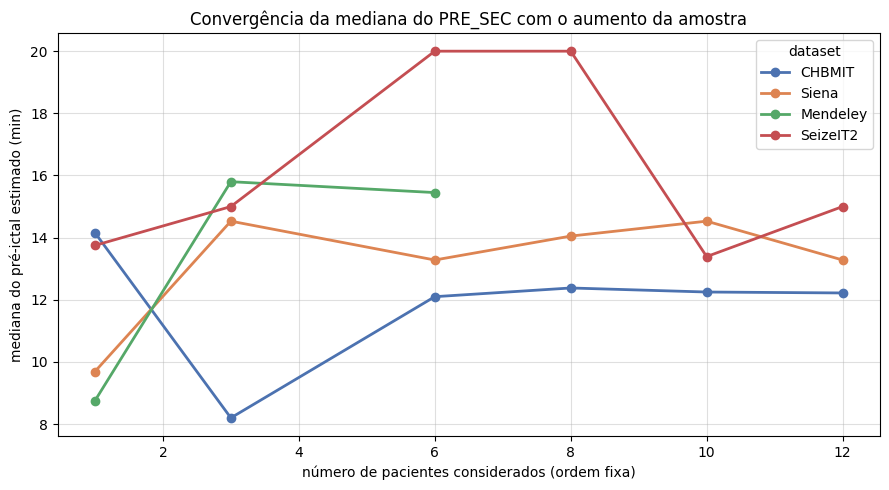

In [5]:
# Mediana cumulativa do pré-ictal estimado por dataset
INCREMENTOS = {
    'CHBMIT'  : [1, 3, 6, 8, 10, 12],
    'Siena'   : [1, 3, 6, 8, 10, 12],
    'SeizeIT2': [1, 3, 6, 8, 10, 12],
    'Mendeley': [1, 3, 6],
}

convergence = []
for ds in DATASETS:
    if ds not in df_calib['dataset'].values:
        continue
    pat_order = PATIENTS[ds]
    for k in INCREMENTOS[ds]:
        subset = pat_order[:k]
        ests = df_calib[(df_calib['dataset'] == ds) & (df_calib['patient'].isin(subset))]['preictal_est_min'].dropna()
        if len(ests) == 0:
            continue
        convergence.append(dict(dataset=ds, n_pacientes=k,
                                n_crises=len(ests),
                                mediana_min=round(float(ests.median()), 2)))
df_conv = pd.DataFrame(convergence)
if df_conv.empty:
    print('Sem dados de convergência (calibração não produziu estimativas).')
else:
    ipd.display(df_conv)

    fig, ax = plt.subplots(figsize=(9, 5))
    for ds in DATASETS:
        sub = df_conv[df_conv['dataset'] == ds]
        if sub.empty:
            continue
        ax.plot(sub['n_pacientes'], sub['mediana_min'], marker='o', linewidth=2,
                color=DS_COLORS[ds], label=ds)
    ax.set_xlabel('número de pacientes considerados (ordem fixa)')
    ax.set_ylabel('mediana do pré-ictal estimado (min)')
    ax.set_title('Convergência da mediana do PRE_SEC com o aumento da amostra')
    ax.legend(title='dataset')
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, 'convergencia_preictal.png'), dpi=140, bbox_inches='tight')
    plt.show()


## 4. Distribuição das estimativas

Estimativa de janela pré-ictal por dataset:


,count,median,mean,std
dataset,,,,
CHBMIT,54,12.2,14.6,9.7
Mendeley,26,15.4,17.1,10.3
SeizeIT2,157,15.0,17.7,11.5
Siena,28,13.3,15.9,10.6


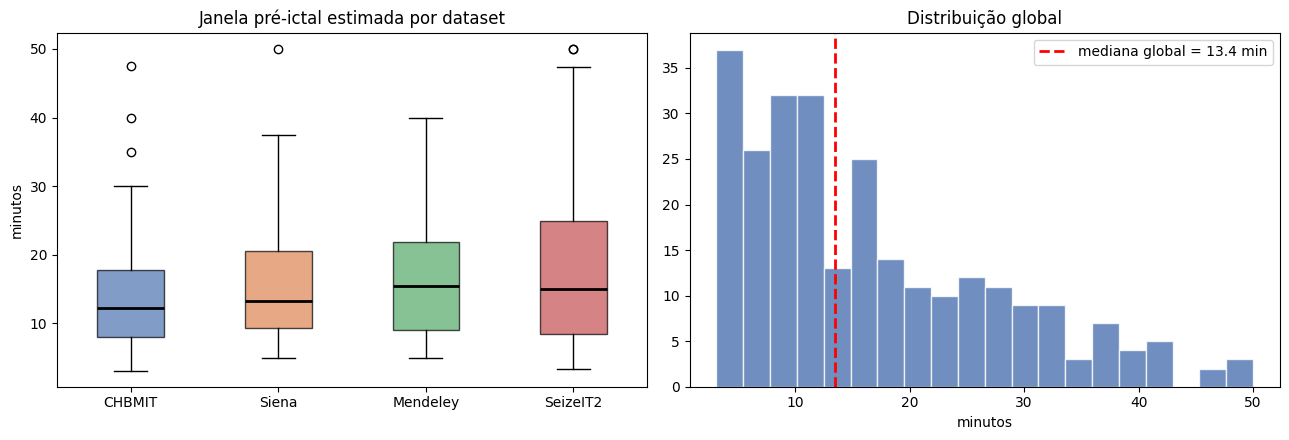

In [6]:
if not df_calib.empty:
    print('Estimativa de janela pré-ictal por dataset:')
    summ = df_calib.groupby('dataset')['preictal_est_min'].agg(['count', 'median', 'mean', 'std']).round(1)
    ipd.display(summ)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    data_box = [df_calib[df_calib['dataset'] == d]['preictal_est_min'].dropna().values
                for d in DATASETS if d in df_calib['dataset'].values]
    labels_box = [d for d in DATASETS if d in df_calib['dataset'].values]
    bp = axes[0].boxplot(data_box, labels=labels_box, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, d in zip(bp['boxes'], labels_box):
        patch.set_facecolor(DS_COLORS[d]); patch.set_alpha(0.7)
    axes[0].set_title('Janela pré-ictal estimada por dataset')
    axes[0].set_ylabel('minutos')
    axes[1].hist(df_calib['preictal_est_min'].dropna(), bins=20, color='#4C72B0', alpha=0.8, edgecolor='white')
    gmed = df_calib['preictal_est_min'].median()
    axes[1].axvline(gmed, color='red', linestyle='--', linewidth=2, label=f'mediana global = {gmed:.1f} min')
    axes[1].set_title('Distribuição global')
    axes[1].set_xlabel('minutos'); axes[1].legend()
    plt.tight_layout(); plt.savefig(os.path.join(VIZ_DIR, 'preictal_estimate.png'), dpi=140, bbox_inches='tight')
    plt.show()
else:
    print('Nenhuma estimativa válida. Verifique os sinais do Notebook 1.')

## 4.1. Estimativa por paciente

A seção 3.1 já mostra a convergência da mediana **por dataset**. Aqui o recorte
é **por paciente** — a evidência direta para a pergunta levantada pelo Paper 2
(Jaddu et al.): existe um pré-ictal universal, ou ele varia de paciente para
paciente? Reporta-se a mediana (e a dispersão) das estimativas do PELT por
`(dataset, paciente)`, e um teste de Kruskal-Wallis comparando a variação
**entre pacientes do mesmo dataset** com a variação **entre datasets** —
se a primeira for tão grande quanto a segunda, colapsar tudo numa única
`PRE_SEC` global é uma simplificação forte, que deve ser discutida no texto.


Estimativa de pré-ictal por paciente (PELT):
(4 paciente(s) com apenas 1 estimativa válida — "std" aparece
 como NaN nesses casos porque desvio-padrão de uma única amostra não é
 definido, não é um erro. Ver a coluna "count" para identificá-los.)


,dataset,patient,count,median,std
0,CHBMIT,chb01,6,14.16,6.50
1,CHBMIT,chb03,4,7.60,2.18
2,CHBMIT,chb04,3,10.00,7.08
3,CHBMIT,chb05,3,10.85,7.95
4,CHBMIT,chb06,7,12.50,9.88
5,CHBMIT,chb07,3,12.25,22.74
6,CHBMIT,chb08,3,25.10,9.70
7,CHBMIT,chb10,7,13.05,11.95
8,CHBMIT,chb11,2,5.82,2.26
9,CHBMIT,chb12,7,13.15,4.16


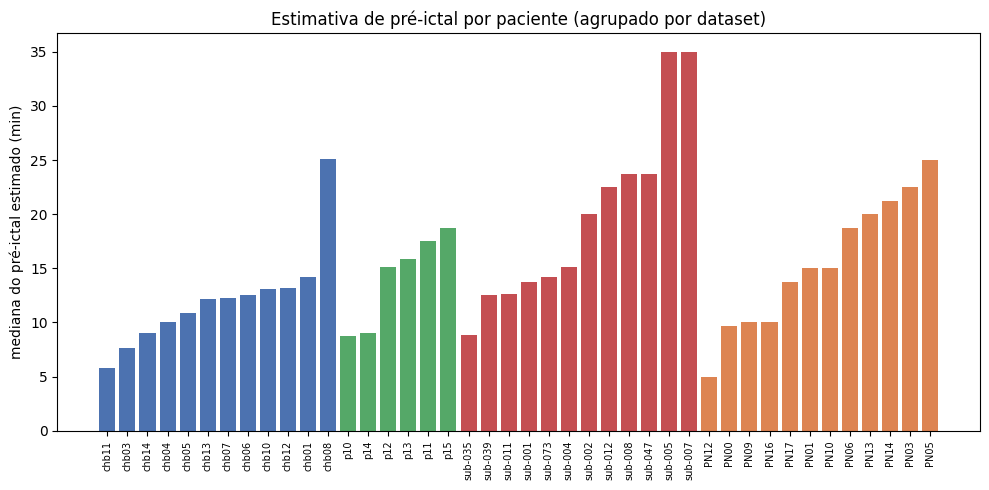

Salvo em: data\logs\preictal_por_paciente.csv

Teste de Kruskal-Wallis (H0: mesma distribuição):
  entre DATASETS:  H=3.11  p=0.3755
  entre PACIENTES de CHBMIT: H=13.35  p=0.2713
  entre PACIENTES de Siena: H=5.14  p=0.6423
  entre PACIENTES de Mendeley: H=5.92  p=0.3144
  entre PACIENTES de SeizeIT2: H=16.49  p=0.1238

p < 0.05 indica que os grupos comparados têm distribuições diferentes —
se isso também vale para pacientes DENTRO do mesmo dataset, é evidência
de que o pré-ictal não é um valor universal, mesmo fixando o dataset.


In [7]:
from scipy.stats import kruskal

if not df_calib.empty:
    df_pat = (df_calib.dropna(subset=['preictal_est_min'])
              .groupby(['dataset', 'patient'])['preictal_est_min']
              .agg(['count', 'median', 'std']).round(2).reset_index())
    n_single = int((df_pat['count'] == 1).sum())
    print('Estimativa de pré-ictal por paciente (PELT):')
    if n_single:
        print(f'({n_single} paciente(s) com apenas 1 estimativa válida — "std" aparece')
        print(' como NaN nesses casos porque desvio-padrão de uma única amostra não é')
        print(' definido, não é um erro. Ver a coluna "count" para identificá-los.)')
    ipd.display(df_pat)

    fig, ax = plt.subplots(figsize=(10, 5))
    order = df_pat.sort_values(['dataset', 'median'])
    colors = [DS_COLORS[d] for d in order['dataset']]
    ax.bar(range(len(order)), order['median'], color=colors)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order['patient'], rotation=90, fontsize=7)
    ax.set_ylabel('mediana do pré-ictal estimado (min)')
    ax.set_title('Estimativa de pré-ictal por paciente (agrupado por dataset)')
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, 'preictal_por_paciente.png'), dpi=140, bbox_inches='tight')
    plt.show()

    df_pat.to_csv(os.path.join(LOG_DIR, 'preictal_por_paciente.csv'), index=False)
    print(f"Salvo em: {os.path.join(LOG_DIR, 'preictal_por_paciente.csv')}")

    # Kruskal-Wallis: variação ENTRE pacientes do mesmo dataset é comparável
    # à variação ENTRE datasets?
    print('\nTeste de Kruskal-Wallis (H0: mesma distribuição):')
    groups_by_dataset = [g['preictal_est_min'].dropna().values
                         for _, g in df_calib.groupby('dataset') if len(g) >= 2]
    if len(groups_by_dataset) >= 2:
        h_ds, p_ds = kruskal(*groups_by_dataset)
        print(f'  entre DATASETS:  H={h_ds:.2f}  p={p_ds:.4f}')
    for ds in DATASETS:
        sub = df_calib[df_calib['dataset'] == ds]
        groups_by_patient = [g['preictal_est_min'].dropna().values
                             for _, g in sub.groupby('patient') if len(g) >= 2]
        if len(groups_by_patient) >= 2:
            h_p, p_p = kruskal(*groups_by_patient)
            print(f'  entre PACIENTES de {ds}: H={h_p:.2f}  p={p_p:.4f}')
        else:
            print(f'  entre PACIENTES de {ds}: dados insuficientes para o teste')
    print('\np < 0.05 indica que os grupos comparados têm distribuições diferentes —')
    print('se isso também vale para pacientes DENTRO do mesmo dataset, é evidência')
    print('de que o pré-ictal não é um valor universal, mesmo fixando o dataset.')
else:
    print('Sem dados de calibração — pule esta seção.')


## 4.2. Diagnóstico de crises descartadas

Cada crise passa por até 3 verificações antes de virar uma estimativa válida
na tabela da seção 4.1: (1) dados suficientes antes da crise, (2) o PELT
detectou algum ponto de mudança, (3) esse ponto caiu dentro da faixa
plausível de `[3, 50]` min. Esta seção mostra, crise a crise, qual dessas
verificações reprovou — é o motivo de alguns pacientes terem `count` baixo
na tabela por paciente, sem que nada tenha dado errado no processamento.


In [8]:
if not df_skip.empty:
    n_total = len(df_calib) + len(df_skip)
    print(f'{len(df_skip)} de {n_total} crises descartadas na calibração '
          f'({len(df_calib)} válidas).\n')

    print('Motivos de descarte (contagem):')
    for motivo, n in df_skip['motivo_descarte'].value_counts().items():
        print(f'  {n:3d}x  {motivo}')

    print('\nCrises válidas x descartadas, por paciente:')
    tot = pd.concat([
        df_calib[['dataset', 'patient']].assign(status='válida'),
        df_skip[['dataset', 'patient']].assign(status='descartada'),
    ])
    resumo_pac = (tot.groupby(['dataset', 'patient', 'status']).size()
                  .unstack(fill_value=0).reset_index())
    for col in ['válida', 'descartada']:
        if col not in resumo_pac.columns:
            resumo_pac[col] = 0
    resumo_pac['total'] = resumo_pac['válida'] + resumo_pac['descartada']
    ipd.display(resumo_pac.sort_values(['dataset', 'patient']))

    print('\nDetalhe de cada crise descartada:')
    cols = ['dataset', 'patient', 'file', 'seizure_idx', 'n_feat_windows',
           'n_changepoints', 'motivo_descarte']
    ipd.display(df_skip[cols].sort_values(['dataset', 'patient', 'seizure_idx']))

    df_skip.to_csv(os.path.join(LOG_DIR, 'crises_descartadas.csv'), index=False)
    resumo_pac.to_csv(os.path.join(LOG_DIR, 'validas_vs_descartadas_por_paciente.csv'), index=False)
    print(f"\nSalvos em: crises_descartadas.csv e validas_vs_descartadas_por_paciente.csv "
          f"(pasta {LOG_DIR})")
else:
    print('Nenhuma crise foi descartada na calibração — todas as estimativas foram válidas.')


220 de 485 crises descartadas na calibração (265 válidas).

Motivos de descarte (contagem):
  153x  PELT não detectou nenhum ponto de mudança na série
   15x  dados insuficientes antes da crise (2 janela(s) de 30s; mínimo necessário: 6)
   12x  dados insuficientes antes da crise (4 janela(s) de 30s; mínimo necessário: 6)
   11x  dados insuficientes antes da crise (1 janela(s) de 30s; mínimo necessário: 6)
    8x  dados insuficientes antes da crise (5 janela(s) de 30s; mínimo necessário: 6)
    7x  dados insuficientes antes da crise (3 janela(s) de 30s; mínimo necessário: 6)
    5x  mudança detectada longe demais da crise (52.5 min > máximo de 50 min; janela analisada tem só 60 min)
    4x  mudança detectada perto demais da crise (2.5 min < mínimo de 3 min)
    3x  dados insuficientes antes da crise (0 janela(s) de 30s; mínimo necessário: 6)
    1x  mudança detectada perto demais da crise (2.8 min < mínimo de 3 min)
    1x  mudança detectada longe demais da crise (57.5 min > máximo de 5

status,dataset,patient,descartada,válida,total
0,CHBMIT,chb01,1,6,7
1,CHBMIT,chb03,3,4,7
2,CHBMIT,chb04,1,3,4
3,CHBMIT,chb05,2,3,5
4,CHBMIT,chb06,3,7,10
5,CHBMIT,chb07,0,3,3
6,CHBMIT,chb08,2,3,5
7,CHBMIT,chb10,0,7,7
8,CHBMIT,chb11,1,2,3
9,CHBMIT,chb12,27,7,34



Detalhe de cada crise descartada:


,dataset,patient,file,seizure_idx,n_feat_windows,n_changepoints,motivo_descarte
0,CHBMIT,chb01,chb01_21,0,10,0,PELT não detectou nenhum ponto de mudança na s...
1,CHBMIT,chb03,chb03_01,0,12,0,PELT não detectou nenhum ponto de mudança na s...
2,CHBMIT,chb03,chb03_03,0,14,0,PELT não detectou nenhum ponto de mudança na s...
3,CHBMIT,chb03,chb03_36,0,57,0,PELT não detectou nenhum ponto de mudança na s...
4,CHBMIT,chb04,chb04_28,0,55,0,PELT não detectou nenhum ponto de mudança na s...
...,...,...,...,...,...,...,...
215,Siena,PN10,PN10-4.5.6,2,120,0,PELT não detectou nenhum ponto de mudança na s...
216,Siena,PN12,PN12-1.2,0,43,0,PELT não detectou nenhum ponto de mudança na s...
217,Siena,PN12,PN12-3,0,25,0,PELT não detectou nenhum ponto de mudança na s...
218,Siena,PN13,PN13-1,0,120,0,PELT não detectou nenhum ponto de mudança na s...



Salvos em: crises_descartadas.csv e validas_vs_descartadas_por_paciente.csv (pasta data\logs)


## 5. Definição de `PRE_SEC`

Adota-se a mediana global das estimativas válidas, limitada ao intervalo [5, 30] min.


In [9]:
if not df_calib.empty:
    PRE_MIN_GLOBAL = float(df_calib['preictal_est_min'].median())
else:
    PRE_MIN_GLOBAL = 30.0
PRE_MIN_GLOBAL = float(np.clip(PRE_MIN_GLOBAL, 5, 30))
PRE_SEC = int(round(PRE_MIN_GLOBAL * 60))

estimate = dict(
    pre_sec=PRE_SEC, pre_min=round(PRE_MIN_GLOBAL, 2),
    n_estimates=int(len(df_calib)),
    n_reliable=int(df_calib['reliable'].sum()) if not df_calib.empty else 0,
    method='mediana global PELT', post_sec=POST_SEC, guard_sec=GUARD_SEC,
)
with open(OUT_JSON, 'w') as f:
    json.dump(estimate, f, indent=2)
print(f'PRE_SEC = {PRE_SEC} s ({PRE_MIN_GLOBAL:.1f} min)')
print(json.dumps(estimate, indent=2))

PRE_SEC = 807 s (13.4 min)
{
  "pre_sec": 807,
  "pre_min": 13.45,
  "n_estimates": 265,
  "n_reliable": 260,
  "method": "mediana global PELT",
  "post_sec": 1200,
  "guard_sec": 300
}


## 6. Funções de rotulagem

Três casos conforme a fonte de interictal:

**Gravação com crise (CHB-MIT, SeizeIT2).** Ictal entre início e fim; pré-ictal
nos `pre_sec` anteriores (após a zona de transição do evento anterior);
pós-ictal nos `POST_SEC` posteriores; interictal a partir de `GAP_FREE_SEC`
(60 min) de distância de qualquer crise — **com a mesma rede de segurança de
margem reduzida que Siena/Mendeley já tinham** (45, depois 30 min), caso a
margem padrão não deixe nenhum interictal sobrando no arquivo. Isso importa
sobretudo para pacientes com poucos arquivos e sem gravação "livre" de crise
disponível como fonte alternativa de interictal.

**Gravação sem crise (CHB-MIT, SeizeIT2).** Sinal inteiro rotulado como
interictal — é a fonte primária de interictal para esses dois datasets; a
margem reduzida acima é só uma rede de segurança para os poucos casos sem
essa fonte disponível.

**Intervalo intra-arquivo (Siena, Mendeley).** Mesma marcação de eventos; o
interictal vem de regiões distantes (antes e depois), com a margem reduzida
progressivamente caso necessário — única fonte de interictal para esses dois
datasets, que não têm gravações sem crise separadas.

**Nota sobre a margem e as 4 janelas pré-ictais.** A margem de segurança
(60 min) não depende da janela pré-ictal escolhida (15/30/45/60 min) — ela é
sempre igual ao maior valor de `PREICTAL_WINDOWS_MIN`, então nunca é menor
que a própria janela sendo rotulada. Isso significa que a disponibilidade de
interictal é a mesma nas 4 janelas para um dado arquivo — o que muda entre
elas é só o tamanho do trecho rotulado como pré-ictal, não o interictal.


In [10]:
def label_seizure_file(n_samples, sfreq, intervals, pre_sec, margins=GAP_FALLBACKS):
    '''Rotula uma gravação com crise. `pre_sec` é a duração da janela pré-ictal
    (em segundos) para ESTA rotulagem — cada janela candidata em
    PREICTAL_WINDOWS_MIN chama esta função uma vez.

    Tenta margens de segurança do interictal decrescentes (GAP_FALLBACKS: 60,
    45, 30 min) caso a margem padrão não deixe nenhum interictal sobrando —
    mesma rede de segurança que já existia só para Siena/Mendeley
    (label_gap_file), agora também para CHB-MIT/SeizeIT2. Isso importa para
    pacientes com poucas gravações e sem arquivo "livre" de crise disponível
    como fonte alternativa de interictal (ex.: um paciente com um único
    arquivo, que já contém a crise).

    Retorna (labels, margem_usada_s, n_amostras_interictal) — mesmo formato
    de label_gap_file, para tratamento uniforme no loop de rotulagem.'''
    pre_n = int(pre_sec * sfreq); post_n = int(POST_SEC * sfreq); guard_n = int(GUARD_SEC * sfreq)
    iv = sorted([(int(o * sfreq), int(e * sfreq)) for o, e in intervals])
    base = np.full(n_samples, LBL['unknown'], dtype=np.int8)
    for (o, e) in iv:
        base[e:min(n_samples, e + post_n)] = LBL['postictal']
    for k, (o, e) in enumerate(iv):
        prev_e = iv[k - 1][1] if k > 0 else 0
        pre_start = max(prev_e + guard_n, o - pre_n)
        if o - pre_start >= int(MIN_PRE_SEC * sfreq):
            base[pre_start:o] = LBL['preictal']
    for (o, e) in iv:
        base[o:e] = LBL['ictal']
    for margin in margins:
        lab = base.copy(); free_n = int(margin * sfreq)
        far = np.ones(n_samples, dtype=bool)
        for (o, e) in iv:
            far[max(0, o - free_n):min(n_samples, e + free_n)] = False
        mask = far & (lab == LBL['unknown'])
        lab[mask] = LBL['interictal']
        n_inter = int((lab == LBL['interictal']).sum())
        if n_inter > 0:
            return lab, margin, n_inter
    return base, margins[-1], 0

def label_free_file(n_samples):
    '''Gravação sem crise: tudo interictal. Não depende de pre_sec (não há
    crise para ancorar uma janela pré-ictal).'''
    return np.full(n_samples, LBL['interictal'], dtype=np.int8)

def label_gap_file(n_samples, sfreq, intervals, pre_sec,
                   margins=GAP_FALLBACKS, post_margin=POST_MARGIN_SEC):
    '''Rotula eventos e marca interictal em regiões distantes (pré e pós-crise).
       Tenta margens decrescentes. Retorna (labels, margem_usada_s, n_amostras_interictal).
       `pre_sec` — ver label_seizure_file.'''
    pre_n = int(pre_sec * sfreq); post_n = int(POST_SEC * sfreq); guard_n = int(GUARD_SEC * sfreq)
    iv = sorted([(int(o * sfreq), int(e * sfreq)) for o, e in intervals])
    base = np.full(n_samples, LBL['unknown'], dtype=np.int8)
    for (o, e) in iv:
        base[e:min(n_samples, e + post_n)] = LBL['postictal']
    for k, (o, e) in enumerate(iv):
        prev_e = iv[k - 1][1] if k > 0 else 0
        pre_start = max(prev_e + guard_n, o - pre_n)
        if o - pre_start >= int(MIN_PRE_SEC * sfreq):
            base[pre_start:o] = LBL['preictal']
    for (o, e) in iv:
        base[o:e] = LBL['ictal']
    for margin in margins:
        lab = base.copy(); free_n = int(margin * sfreq); pm_n = int(post_margin * sfreq)
        far = np.ones(n_samples, dtype=bool)
        for (o, e) in iv:
            far[max(0, o - free_n):min(n_samples, e + max(free_n, pm_n))] = False
        mask = far & (lab == LBL['unknown'])
        lab[mask] = LBL['interictal']
        n_inter = int((lab == LBL['interictal']).sum())
        if n_inter > 0:
            return lab, margin, n_inter
    return base, margins[-1], 0

print('Funções de rotulagem definidas (agora parametrizadas por pre_sec).')

Funções de rotulagem definidas (agora parametrizadas por pre_sec).


## 7. Rotulagem e gravação

Cada sinal é rotulado conforme sua fonte de interictal e gravado em `_L1.npz`. Casos de intervalo intra-arquivo com margem reduzida ou sem interictal são registrados em log.


In [11]:
gap_log = []; summary = []

def patient_in_target(ds, pat):
    return ds in PATIENTS and pat in PATIENTS[ds]

def l1_path(ds, pat, fkey, w_min):
    '''Nome do _L1.npz para uma janela pré-ictal específica (em minutos).
    Ex.: CHBMIT__chb01__chb01_01_L1_w30.npz para a janela de 30 min.'''
    return os.path.join(L1_DIR, f'{ds}__{pat}__{fkey}_L1_w{w_min}.npz')

signal_files = sorted(glob.glob(os.path.join(SIGNAL_DIR, '*_signal.npz')))
total_tasks = len(signal_files) * len(PREICTAL_WINDOWS_MIN)
print(f'{len(signal_files)} gravações x {len(PREICTAL_WINDOWS_MIN)} janelas '
      f'{PREICTAL_WINDOWS_MIN} min = {total_tasks} rotulagens a verificar/gerar.\n')

pbar = tqdm(signal_files, desc='Rotulagem')
for npz_path in pbar:
    base = os.path.basename(npz_path)
    m = re.match(r'(.+?)__(.+?)__(.+)_signal\.npz', base)
    if not m:
        continue
    ds, pat, fkey = m.group(1), m.group(2), m.group(3)
    if not patient_in_target(ds, pat):
        continue

    # Pula a gravação inteira se TODAS as janelas já foram geradas antes.
    pending_windows = [w for w in PREICTAL_WINDOWS_MIN
                       if not os.path.exists(l1_path(ds, pat, fkey, w))]
    if not pending_windows:
        continue

    try:
        # Carregar apenas metadados leves — NÃO carregar o array 'data'
        npz   = np.load(npz_path, allow_pickle=True)
        sfreq = float(npz['sfreq'])
        chs   = list(npz['ch_names'])
        seiz  = npz['seizure_intervals']
        n     = int(npz['data'].shape[1])     # shape não carrega o array completo no npz lazy
        iv    = [(float(s), float(e)) for s, e in seiz] if len(seiz) > 0 else []
        npz.close(); del npz; gc.collect()    # libera imediatamente — não precisamos do sinal
    except Exception as e:
        print(f'  {base}: {e}'); continue

    for w_min in pending_windows:
        pre_sec = w_min * 60
        out = l1_path(ds, pat, fkey, w_min)

        # Gerar vetor de rótulos (apenas int8 — mínimo de RAM)
        if not iv:
            labels = label_free_file(n)
        elif ds in GAP_DATASETS:
            labels, margin, _ = label_gap_file(n, sfreq, iv, pre_sec)
            gap_log.append(dict(dataset=ds, patient=pat, file=fkey, window_min=w_min,
                                margin_min=margin // 60,
                                interictal_min=round(int((labels == 0).sum()) / sfreq / 60, 1)))
        else:
            labels, margin, _ = label_seizure_file(n, sfreq, iv, pre_sec)
            if margin < GAP_FREE_SEC:
                # só loga quando a margem padrão (60 min) não foi suficiente —
                # evita milhares de linhas triviais quando tudo correu bem
                gap_log.append(dict(dataset=ds, patient=pat, file=fkey, window_min=w_min,
                                    margin_min=margin // 60,
                                    interictal_min=round(int((labels == 0).sum()) / sfreq / 60, 1)))

        # _L1.npz guarda apenas rótulos e metadados — NÃO o sinal.
        # O NB3 lê o sinal diretamente do _signal.npz original.
        np.savez_compressed(
            out,
            labels=labels,
            sfreq=np.float32(sfreq),
            ch_names=np.array(chs),
            dataset=np.str_(ds),
            n_samples=np.int64(n),
            preictal_window_min=np.int64(w_min),
        )
        summary.append(dict(dataset=ds, patient=pat, file=fkey, window_min=w_min,
                            n_pre=int((labels == 1).sum()), n_ictal=int((labels == 2).sum()),
                            n_inter=int((labels == 0).sum()),
                            pre_min=round((labels == 1).sum() / sfreq / 60, 1),
                            inter_min=round((labels == 0).sum() / sfreq / 60, 1)))
        del labels
    gc.collect()

print(f'Rotulagem concluída: {len(summary)} arquivos _L1.npz gerados '
      f'({len(PREICTAL_WINDOWS_MIN)} janelas x gravações processadas).')

352 gravações x 4 janelas [10, 15, 30, 45] min = 1408 rotulagens a verificar/gerar.



Rotulagem: 100%|██████████| 352/352 [05:34<00:00,  1.05it/s]

Rotulagem concluída: 1408 arquivos _L1.npz gerados (4 janelas x gravações processadas).


## 8. Resumo da rotulagem

In [12]:
df_sum = pd.DataFrame(summary)
if not df_sum.empty:
    print('Resumo por dataset e janela pré-ictal (minutos por classe):')
    g = df_sum.groupby(['dataset', 'window_min']).agg(
        arquivos=('file', 'count'),
        preictal_min=('pre_min', 'sum'),
        interictal_min=('inter_min', 'sum'),
        amostras_pre=('n_pre', 'sum'),
        amostras_inter=('n_inter', 'sum')).round(1).reset_index()
    ipd.display(g)
    df_sum.to_csv(os.path.join(LOG_DIR, 'rotulagem_resumo.csv'), index=False)

if gap_log:
    df_gap = pd.DataFrame(gap_log)
    # a partir de agora df_gap cobre os 4 datasets: Siena/Mendeley sempre
    # aparecem aqui (usam sempre esse mecanismo); CHB-MIT/SeizeIT2 só aparecem
    # quando a margem padrão de 60 min não deixou interictal suficiente.
    zero = df_gap[df_gap['interictal_min'] == 0]
    print(f'\nCasos com margem de interictal reduzida (< 60 min): {len(df_gap)} '
          f'(dataset, paciente, arquivo, janela)')
    ipd.display(df_gap.groupby('dataset').size().rename('n_casos'))
    print(f'\n  sem interictal mesmo após todas as margens tentadas: {len(zero)}')
    if len(zero):
        print('  esses ficarão de fora do treino/teste para a(s) janela(s) indicada(s)')
        print('  (NB3 registra isso em exclusoes_nb3.csv, não é um erro):')
        ipd.display(zero)
    df_gap.to_csv(os.path.join(LOG_DIR, 'gap_log.csv'), index=False)

print('\nRotulagem concluída. Salvo em level1_signals. Próximo: Notebook 3 - Features.')

Resumo por dataset e janela pré-ictal (minutos por classe):


,dataset,window_min,arquivos,preictal_min,interictal_min,amostras_pre,amostras_inter
0,CHBMIT,10,171,715.1,12102.3,10984192,185893376
1,CHBMIT,15,171,1022.5,12102.3,15706880,185893376
2,CHBMIT,30,171,1749.3,12102.3,26876672,185893376
3,CHBMIT,45,171,2163.5,12047.3,33242368,185045760
4,Mendeley,10,20,330.0,669.7,5068800,10286848
5,Mendeley,15,20,495.0,669.7,7603200,10286848
6,Mendeley,30,20,939.9,669.7,14437632,10286848
7,Mendeley,45,20,1305.4,664.2,20051456,10202112
8,SeizeIT2,10,122,1870.7,43815.6,28737280,673008128
9,SeizeIT2,15,122,2715.2,43815.6,41706752,673008128



Casos com margem de interictal reduzida (< 60 min): 500 (dataset, paciente, arquivo, janela)


dataset
CHBMIT      224
Mendeley     80
SeizeIT2     48
Siena       148
Name: n_casos, dtype: int64


  sem interictal mesmo após todas as margens tentadas: 100
  esses ficarão de fora do treino/teste para a(s) janela(s) indicada(s)
  (NB3 registra isso em exclusoes_nb3.csv, não é um erro):


,dataset,patient,file,window_min,margin_min,interictal_min
16,CHBMIT,chb01,chb01_18,10,30,0.0
17,CHBMIT,chb01,chb01_18,15,30,0.0
18,CHBMIT,chb01,chb01_18,30,30,0.0
19,CHBMIT,chb01,chb01_18,45,30,0.0
112,CHBMIT,chb11,chb11_99,10,30,0.0
...,...,...,...,...,...,...
371,Siena,PN00,PN00-5,45,30,0.0
448,Siena,PN12,PN12-3,10,30,0.0
449,Siena,PN12,PN12-3,15,30,0.0
450,Siena,PN12,PN12-3,30,30,0.0



Rotulagem concluída. Salvo em level1_signals. Próximo: Notebook 3 - Features.
